In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [33]:
energy_dataset = pd.read_csv("energy_dataset.csv")
energy_dataset

,time,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_coal-derived_gas,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_fossil_oil_shale,generation_fossil_peat,generation_geothermal,...,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_offshore,generation_wind_onshore,forecast_wind_offshore_eday_ahead,total_load_actual,price_day_ahead
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,NaN,25385.0,50.10
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,NaN,24382.0,48.10
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,NaN,22734.0,47.33
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,NaN,21286.0,42.27
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,NaN,20264.0,38.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,297.0,0.0,0.0,7634.0,2628.0,178.0,0.0,0.0,0.0,...,6073.0,63.0,95.0,85.0,277.0,0.0,3113.0,NaN,30653.0,68.85
35060,2018-12-31 20:00:00+01:00,296.0,0.0,0.0,7241.0,2566.0,174.0,0.0,0.0,0.0,...,6074.0,62.0,95.0,33.0,280.0,0.0,3288.0,NaN,29735.0,68.40
35061,2018-12-31 21:00:00+01:00,292.0,0.0,0.0,7025.0,2422.0,168.0,0.0,0.0,0.0,...,6076.0,61.0,94.0,31.0,286.0,0.0,3503.0,NaN,28071.0,66.88
35062,2018-12-31 22:00:00+01:00,293.0,0.0,0.0,6562.0,2293.0,163.0,0.0,0.0,0.0,...,6075.0,61.0,93.0,31.0,287.0,0.0,3586.0,NaN,25801.0,63.93


In [34]:
print("Number of predictors:", energy_dataset.shape[1])

missing_values_df = energy_dataset.isnull().sum()
print(missing_values_df)

print("Dataset statistics")
energy_dataset.describe().T

Number of predictors: 25
time                                               0
generation_biomass                                19
generation_fossil_brown_coal_lignite              18
generation_fossil_coal-derived_gas                18
generation_fossil_gas                             18
generation_fossil_hard_coal                       18
generation_fossil_oil                             19
generation_fossil_oil_shale                       18
generation_fossil_peat                            18
generation_geothermal                             18
generation_hydro_pumped_storage_aggregated     35064
generation_hydro_pumped_storage_consumption       19
generation_hydro_run-of-river_and_poundage        19
generation_hydro_water_reservoir                  18
generation_marine                                 19
generation_nuclear                                17
generation_other                                  18
generation_other_renewable                        18
generation_solar     

,count,mean,std,min,25%,50%,75%,max
generation_biomass,35045.0,383.513540,85.353943,0.00,333.00,367.00,433.00,592.00
generation_fossil_brown_coal_lignite,35046.0,448.059208,354.568590,0.00,0.00,509.00,757.00,999.00
generation_fossil_coal-derived_gas,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_fossil_gas,35046.0,5622.737488,2201.830478,0.00,4126.00,4969.00,6429.00,20034.00
generation_fossil_hard_coal,35046.0,4256.065742,1961.601013,0.00,2527.00,4474.00,5838.75,8359.00
generation_fossil_oil,35045.0,298.319789,52.520673,0.00,263.00,300.00,330.00,449.00
generation_fossil_oil_shale,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_fossil_peat,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_geothermal,35046.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
generation_hydro_pumped_storage_aggregated,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- There are columns where all values are missing: forecast_wind_offshore_eday_ahead, generation_hydro_pumped_storage_aggregated;
- By the descriptive statistics it is also possible to ensure that the variables generation_fossil_coal-derived_gas, generation_fossil_oil_shale, generation_fossil_peat, generation_geothermal, generation_marine and generation_wind_offshore have all the values as 0.

For that reason the following columns will be removed:
[forecast_wind_offshore_eday_ahead, generation_hydro_pumped_storage_aggregated, generation_fossil_coal-derived_gas, generation_fossil_oil_shale, generation_fossil_peat, generation_geothermal, generation_marine, generation_wind_offshore].

In [35]:
features_to_remove = ['forecast_wind_offshore_eday_ahead', 'generation_hydro_pumped_storage_aggregated', 'generation_fossil_coal-derived_gas', 
                      'generation_fossil_oil_shale', 'generation_fossil_peat', 'generation_geothermal', 'generation_marine', 'generation_wind_offshore']
print(energy_dataset.columns)
energy_dataset = energy_dataset.drop(features_to_remove, axis = 1)
print(energy_dataset.columns)
energy_dataset

Index(['time', 'generation_biomass', 'generation_fossil_brown_coal_lignite',
       'generation_fossil_coal-derived_gas', 'generation_fossil_gas',
       'generation_fossil_hard_coal', 'generation_fossil_oil',
       'generation_fossil_oil_shale', 'generation_fossil_peat',
       'generation_geothermal', 'generation_hydro_pumped_storage_aggregated',
       'generation_hydro_pumped_storage_consumption',
       'generation_hydro_run-of-river_and_poundage',
       'generation_hydro_water_reservoir', 'generation_marine',
       'generation_nuclear', 'generation_other', 'generation_other_renewable',
       'generation_solar', 'generation_waste', 'generation_wind_offshore',
       'generation_wind_onshore', 'forecast_wind_offshore_eday_ahead',
       'total_load_actual', 'price_day_ahead'],
      dtype='object')
Index(['time', 'generation_biomass', 'generation_fossil_brown_coal_lignite',
       'generation_fossil_gas', 'generation_fossil_hard_coal',
       'generation_fossil_oil', 'generatio

,time,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_hydro_pumped_storage_consumption,generation_hydro_run-of-river_and_poundage,generation_hydro_water_reservoir,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_onshore,total_load_actual,price_day_ahead
0,2015-01-01 00:00:00+01:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10
1,2015-01-01 01:00:00+01:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10
2,2015-01-01 02:00:00+01:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33
3,2015-01-01 03:00:00+01:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27
4,2015-01-01 04:00:00+01:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,297.0,0.0,7634.0,2628.0,178.0,1.0,1135.0,4836.0,6073.0,63.0,95.0,85.0,277.0,3113.0,30653.0,68.85
35060,2018-12-31 20:00:00+01:00,296.0,0.0,7241.0,2566.0,174.0,1.0,1172.0,3931.0,6074.0,62.0,95.0,33.0,280.0,3288.0,29735.0,68.40
35061,2018-12-31 21:00:00+01:00,292.0,0.0,7025.0,2422.0,168.0,50.0,1148.0,2831.0,6076.0,61.0,94.0,31.0,286.0,3503.0,28071.0,66.88
35062,2018-12-31 22:00:00+01:00,293.0,0.0,6562.0,2293.0,163.0,108.0,1128.0,2068.0,6075.0,61.0,93.0,31.0,287.0,3586.0,25801.0,63.93


In [29]:
weather_dataset = pd.read_csv("weather.csv")
weather_dataset

,time,temperature,pressure,humidity,wind_speed
0,2015-01-01 00:00:00+01:00,272.491463,1021.3,82.4,2.0
1,2015-01-01 01:00:00+01:00,272.512700,1021.2,82.4,2.0
2,2015-01-01 02:00:00+01:00,272.151937,1021.6,82.0,2.4
3,2015-01-01 03:00:00+01:00,272.142269,1021.5,82.0,2.4
4,2015-01-01 04:00:00+01:00,272.198700,1021.5,82.0,2.4
...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,284.470000,1029.2,73.6,1.4
35060,2018-12-31 20:00:00+01:00,282.294000,1030.0,68.0,1.8
35061,2018-12-31 21:00:00+01:00,280.850000,1029.8,71.4,2.6
35062,2018-12-31 22:00:00+01:00,279.718000,1030.2,70.0,2.8


In [36]:
print("Number of predictors:", weather_dataset.shape[1])

missing_values_df = weather_dataset.isnull().sum()
print(missing_values_df)

print("Dataset statistics")
weather_dataset.describe().T

Number of predictors: 5
time           0
temperature    0
pressure       0
humidity       0
wind_speed     0
dtype: int64
Dataset statistics


,count,mean,std,min,25%,50%,75%,max
temperature,35064.0,289.706862,7.251796,272.006,284.098877,289.0362,295.1005,309.048
pressure,35064.0,1017.297872,6.363845,999.500,1013.475000,1017.0000,1021.0000,1035.500
humidity,35064.0,68.033025,14.814871,22.600,56.750000,69.6000,80.0000,100.000
wind_speed,35064.0,2.442944,1.276415,0.000,1.400000,2.2000,3.2000,8.500


In [45]:
df = pd.merge(energy_dataset, weather_dataset, on="time", how="inner")
df['time'] = pd.to_datetime(df['time'], utc = True)
df.set_index('time', inplace=True)
df

,generation_biomass,generation_fossil_brown_coal_lignite,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_hydro_pumped_storage_consumption,generation_hydro_run-of-river_and_poundage,generation_hydro_water_reservoir,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_onshore,total_load_actual,price_day_ahead,temperature,pressure,humidity,wind_speed
time,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10,272.491463,1021.3,82.4,2.0
2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10,272.512700,1021.2,82.4,2.0
2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33,272.151937,1021.6,82.0,2.4
2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27,272.142269,1021.5,82.0,2.4
2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41,272.198700,1021.5,82.0,2.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 18:00:00+00:00,297.0,0.0,7634.0,2628.0,178.0,1.0,1135.0,4836.0,6073.0,63.0,95.0,85.0,277.0,3113.0,30653.0,68.85,284.470000,1029.2,73.6,1.4
2018-12-31 19:00:00+00:00,296.0,0.0,7241.0,2566.0,174.0,1.0,1172.0,3931.0,6074.0,62.0,95.0,33.0,280.0,3288.0,29735.0,68.40,282.294000,1030.0,68.0,1.8
2018-12-31 20:00:00+00:00,292.0,0.0,7025.0,2422.0,168.0,50.0,1148.0,2831.0,6076.0,61.0,94.0,31.0,286.0,3503.0,28071.0,66.88,280.850000,1029.8,71.4,2.6


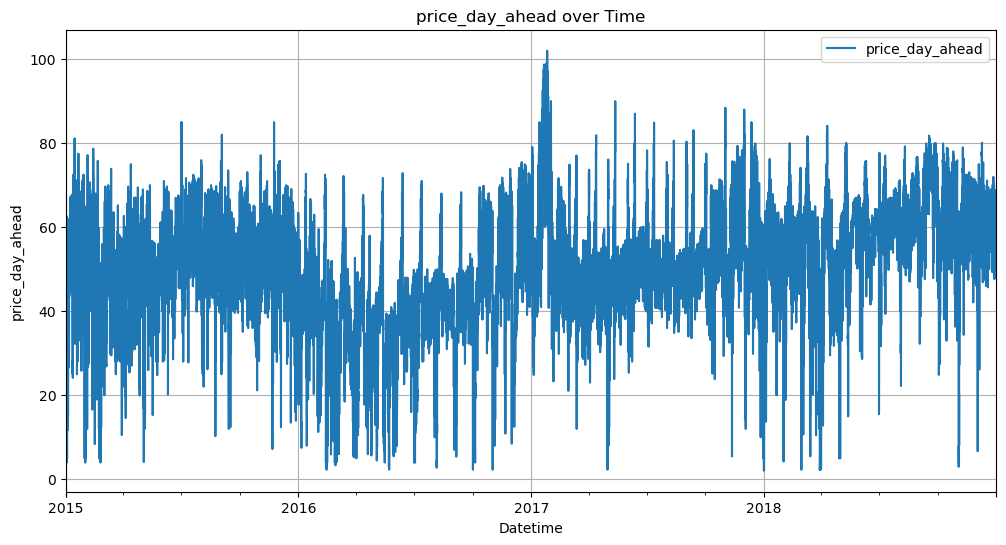

In [47]:
df.plot(y='price_day_ahead', figsize=(12, 6), title='price_day_ahead over Time')
plt.xlabel('Datetime')
plt.ylabel('price_day_ahead')
plt.grid(True)
plt.show()

From the time series graphic we can see the evolution of price_day_ahead over time. Is it possible to verify seasonal patterns over the years but we will plot the rolling mean and standard derivation using different window lengths in order to highlight recurring patterns.

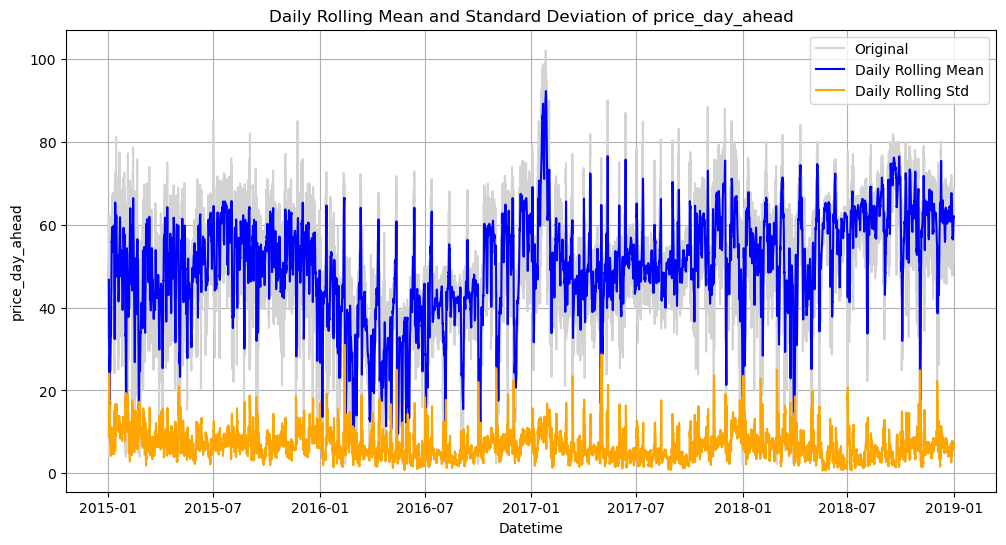

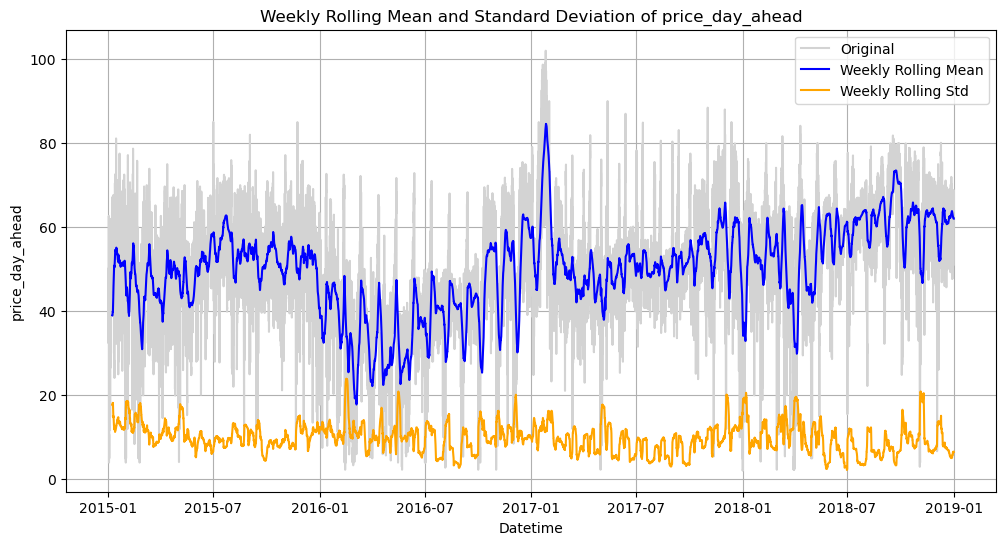

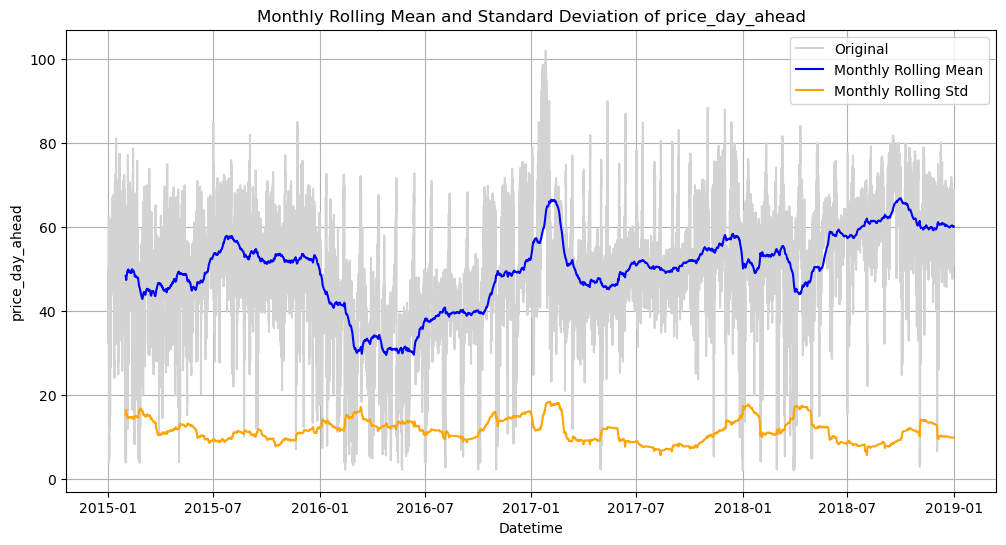

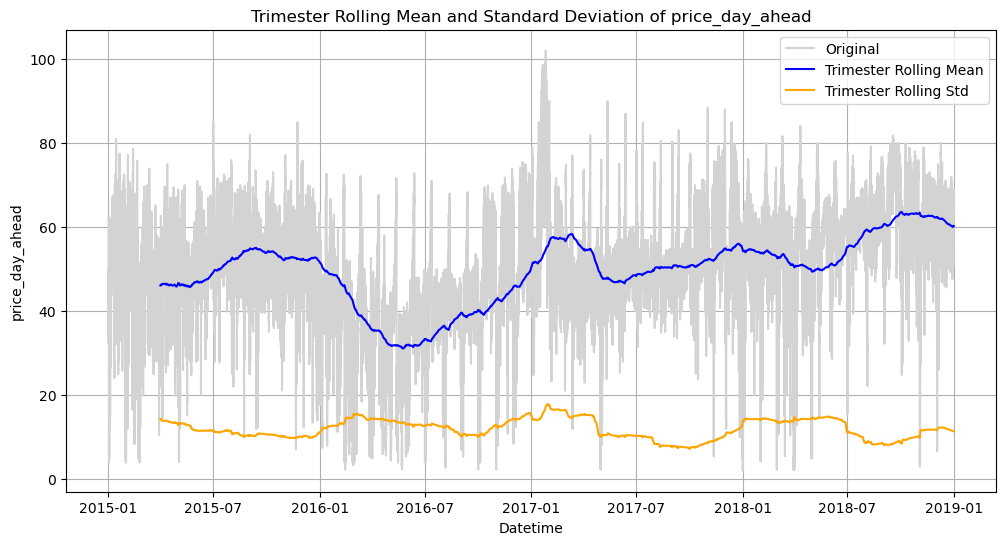

In [54]:
time_windows = {
    24: 'Daily',
    168: 'Weekly',    
    720: 'Monthly',    
    2160: 'Trimester'
}

for time_win, freq in time_windows.items():
    rolling_mean = df['price_day_ahead'].rolling(window=time_win).mean()
    rolling_std = df['price_day_ahead'].rolling(window=time_win).std()
    
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['price_day_ahead'], color='lightgray', label='Original')
    plt.plot(df.index, rolling_mean, color='blue', label=f'{freq} Rolling Mean')
    plt.plot(df.index, rolling_std, color='orange', label=f'{freq} Rolling Std')
    
    plt.title(f'{freq} Rolling Mean and Standard Deviation of price_day_ahead')
    plt.xlabel('Datetime')
    plt.ylabel('price_day_ahead')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
## Comentário da sazonalidade

In [ ]:
# Decomposição da séria temporal

In [ ]:
# Com o exemplo da divisão mensal ou semanal, fazer um gráfico com as variáveis exógenas para perceber tendências e comentar

##### Missing Values

In a time series, missing values can represent gaps or interruptions, which may distort analysis and forecasting if not properly handled. To address this, we will use nearest interpolation.

Nearest Interpolation works by filling missing values with the closest observed value, combining the effects of both forward and backward filling. This approach helps to:
- Maintain the consistency of trends and tendencies in the data
- Avoid introducing artificial jumps or smoothing that could distort short-term dynamics

In [59]:
print('Dataset missing values')
missing_values_df = df.isnull().sum()
print(missing_values_df)

df = df.interpolate(method='nearest')

print()
print('Dataset after missing values being filled using Nearest Interpolation')
print(df.isnull().sum())

Dataset missing values
generation_biomass                             19
generation_fossil_brown_coal_lignite           18
generation_fossil_gas                          18
generation_fossil_hard_coal                    18
generation_fossil_oil                          19
generation_hydro_pumped_storage_consumption    19
generation_hydro_run-of-river_and_poundage     19
generation_hydro_water_reservoir               18
generation_nuclear                             17
generation_other                               18
generation_other_renewable                     18
generation_solar                               18
generation_waste                               19
generation_wind_onshore                        18
total_load_actual                              36
price_day_ahead                                 0
temperature                                     0
pressure                                        0
humidity                                        0
wind_speed                 

##### Data Split
The final 12 months will be used as test set. The remaining data will be used as training set.

In [69]:
# Number of months to use as test set
test_size = 2* 365 * 24 - 1

train = df.iloc[:-test_size]  # all rows except last 24 months
test = df.iloc[-test_size:]   # last 24 months

print(f"Training set shape: {train.shape}")
print(f"Test set shape: {test.shape}")
print(f"Training period: {train.index.min()} to {train.index.max()}")
print(f"Test period: {test.index.min()} to {test.index.max()}")

Training set shape: (17545, 20)
Test set shape: (17519, 20)
Training period: 2014-12-31 23:00:00+00:00 to 2016-12-31 23:00:00+00:00
Test period: 2017-01-01 00:00:00+00:00 to 2018-12-31 22:00:00+00:00


##### Feature Selection

In [74]:
## Lasso regularization